<a href="https://colab.research.google.com/github/ycai4891-tech/roi-scenario-engine/blob/main/roi_scenario_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import itertools

# ---- SYNTHETIC ASSUMPTIONS (illustrative only, not client data) ----
HARDWARE_PER_UNIT = 40000     # GBP
SETUP_PER_UNIT    = 5000      # USD
FX_GBP_USD        = 1.25

SUB_TERMS = {'1yr': 15000, '2yr': 12750, '3yr': 11900, '5yr': 11200}  # USD/site/yr
BENEFITS  = {'conservative': 45000, 'moderate': 75000, 'optimistic': 110000}
SITES     = [4, 8, 16, 32]
YEARS     = 3

rows = []
for term, sub in SUB_TERMS.items():
    for case, annual_benefit in BENEFITS.items():
        for n in SITES:
            hardware = HARDWARE_PER_UNIT * FX_GBP_USD * n
            setup    = SETUP_PER_UNIT * n
            subs     = sub * n * YEARS
            cost     = hardware + setup + subs

            benefit  = annual_benefit * n * YEARS
            net      = benefit - cost

            rows.append({
                'term': term,
                'case': case,
                'sites': n,
                'cost': round(cost, 2),
                'benefit': round(benefit, 2),
                'net_benefit': round(net, 2),
                'roi_pct': round(net / cost * 100, 2),
                'payback_years': round(cost / (annual_benefit * n), 2),
            })

df = pd.DataFrame(rows)
print(f'{len(df)} scenarios generated\n')
print(df.sort_values('roi_pct', ascending=False).head(10).to_string(index=False))
df.to_csv('roi_scenarios.csv', index=False)

48 scenarios generated

term       case  sites      cost  benefit  net_benefit  roi_pct  payback_years
 5yr optimistic      4  354400.0  1320000     965600.0   272.46           0.81
 5yr optimistic      8  708800.0  2640000    1931200.0   272.46           0.81
 5yr optimistic     16 1417600.0  5280000    3862400.0   272.46           0.81
 5yr optimistic     32 2835200.0 10560000    7724800.0   272.46           0.81
 3yr optimistic      4  362800.0  1320000     957200.0   263.84           0.82
 3yr optimistic      8  725600.0  2640000    1914400.0   263.84           0.82
 3yr optimistic     16 1451200.0  5280000    3828800.0   263.84           0.82
 3yr optimistic     32 2902400.0 10560000    7657600.0   263.84           0.82
 2yr optimistic      4  373000.0  1320000     947000.0   253.89           0.85
 2yr optimistic      8  746000.0  2640000    1894000.0   253.89           0.85


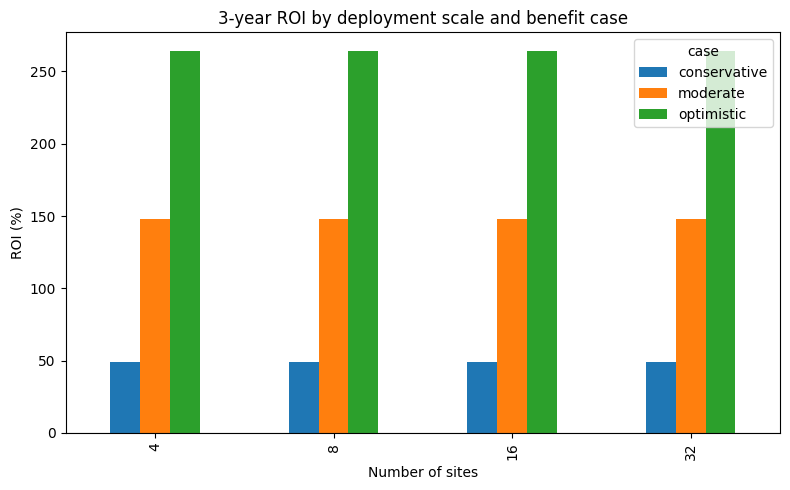

In [2]:
import matplotlib.pyplot as plt

pivot = df[df.term == '3yr'].pivot(index='sites', columns='case', values='roi_pct')
ax = pivot.plot(kind='bar', figsize=(8, 5))
ax.set_ylabel('ROI (%)')
ax.set_xlabel('Number of sites')
ax.set_title('3-year ROI by deployment scale and benefit case')
ax.axhline(0, color='grey', linewidth=0.8)
plt.tight_layout()
plt.savefig('roi_by_scale.png', dpi=150)
plt.show()